1. 先讀入真實設計點，只保留鄉鎮、年份、經緯度

In [2]:
import numpy as np
import pandas as pd

# =========================
# 0) 讀取真實 LC 資料，只拿設計點
# =========================
file_path = r"C:/Users/User/Desktop/LC analysis/gdf_table_符合水痘_死亡資料變換可數型.xlsx"

df_raw = pd.read_excel(file_path).copy()

required_cols = ["年份", "鄉鎮", "經度", "緯度"]
missing = [c for c in required_cols if c not in df_raw.columns]
if missing:
    raise ValueError(f"缺少必要欄位: {missing}")

df_raw["年份"] = pd.to_datetime(df_raw["年份"], errors="coerce")
df_raw = df_raw.dropna(subset=["年份", "鄉鎮", "經度", "緯度"]).copy()
df_raw["year_num"] = df_raw["年份"].dt.year.astype(int)

# 只保留模擬需要的設計點
design_df = df_raw[["年份", "year_num", "鄉鎮", "經度", "緯度"]].copy()

print(design_df.head())
print(design_df.shape)

          年份  year_num      鄉鎮          經度         緯度
0 2016-01-01      2016  屏東縣滿州鄉  120.843568  22.049300
1 2016-01-01      2016  新竹縣北埔鄉  121.064274  24.672074
2 2017-01-01      2017  宜蘭縣三星鄉  121.664271  24.667720
3 2017-01-01      2017  屏東縣來義鄉  120.685723  22.501572
4 2018-01-01      2018  宜蘭縣員山鄉  121.661228  24.741992
(1297, 5)


2. 標準化空間與時間座標

In [3]:
# =========================
# 1) 標準化座標
# =========================
design_df["x"] = (design_df["經度"] - design_df["經度"].mean()) / design_df["經度"].std(ddof=0)
design_df["y"] = (design_df["緯度"] - design_df["緯度"].mean()) / design_df["緯度"].std(ddof=0)
design_df["tau"] = (design_df["year_num"] - design_df["year_num"].mean()) / design_df["year_num"].std(ddof=0)

print(design_df[["經度", "緯度", "year_num", "x", "y", "tau"]].head())

           經度         緯度  year_num         x         y       tau
0  120.843568  22.049300      2016  0.090059 -2.045876 -0.419319
1  121.064274  24.672074      2016  0.547324  0.988767 -0.419319
2  121.664271  24.667720      2017  1.790411  0.983728  0.475182
3  120.685723  22.501572      2017 -0.236967 -1.522582  0.475182
4  121.661228  24.741992      2018  1.784106  1.069665  1.369682


3. 定義三種情境的真實 𝐹 和 𝑃

In [4]:
# =========================
# 2) 定義工具函數
# =========================
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def get_true_F_P(df, scenario="A"):
    x = df["x"].to_numpy()
    y = df["y"].to_numpy()
    tau = df["tau"].to_numpy()

    if scenario == "A":
        # 低膨脹、簡單時空結構
        F_true = (
            -3.2
            + 0.5 * np.sin(x)
            + 0.4 * np.cos(y)
            + 0.25 * tau
        )
        eta_p = (
            -2.3
            + 0.5 * np.sin(x)
            - 0.3 * np.cos(y)
            + 0.3 * tau
        )
        sigma = 0.30

    elif scenario == "B":
        # 中度膨脹、非線性 + 一點交互作用
        F_true = (
            -3.0
            + 0.7 * np.sin(x)
            + 0.6 * np.cos(y)
            + 0.35 * tau
            + 0.25 * x * tau
        )
        eta_p = (
            -1.3
            + 0.8 * np.sin(x)
            - 0.5 * np.cos(y)
            + 0.4 * tau
        )
        sigma = 0.35

    elif scenario == "C":
        # 高膨脹、較複雜時空交互作用
        F_true = (
            -2.8
            + 0.8 * np.sin(x)
            + 0.6 * np.cos(y)
            + 0.4 * tau
            + 0.35 * x * tau
            - 0.25 * y * tau
        )
        eta_p = (
            -0.4
            + 1.0 * np.sin(x)
            - 0.7 * np.cos(y)
            + 0.5 * tau
            + 0.4 * x * tau
        )
        sigma = 0.40

    else:
        raise ValueError("scenario 只能是 'A', 'B', 'C'")

    P_true = sigmoid(eta_p)
    return F_true, P_true, sigma

4. 用 mixture 機制生成模擬資料

In [5]:
# =========================
# 3) 生成模擬資料
# =========================
INFLATED_C = -6.907255070523717

def simulate_one_dataset(design_df, scenario="A", seed=1234, c=INFLATED_C):
    rng = np.random.default_rng(seed)

    out = design_df.copy()

    F_true, P_true, sigma = get_true_F_P(out, scenario=scenario)

    # 先抽是否為膨脹點
    Z = rng.binomial(n=1, p=P_true, size=len(out))

    # 再生成觀測值
    y_cont = rng.normal(loc=F_true, scale=sigma, size=len(out))
    y_sim = np.where(Z == 1, c, y_cont)

    out["scenario"] = scenario
    out["F_true"] = F_true
    out["P_true"] = P_true
    out["sigma_true"] = sigma
    out["inflated_true"] = Z
    out["y_sim"] = y_sim

    # 給你之後直接當 target_col 用
    out["死亡_cll_sim"] = out["y_sim"]

    return out


5. 先生成一份資料看看

In [6]:
# =========================
# 4) 試生成一份資料
# =========================
sim_A = simulate_one_dataset(design_df, scenario="A", seed=2026)
sim_B = simulate_one_dataset(design_df, scenario="B", seed=2026)
sim_C = simulate_one_dataset(design_df, scenario="C", seed=2026)

print(sim_A.head())

for name, d in [("A", sim_A), ("B", sim_B), ("C", sim_C)]:
    print(f"\nScenario {name}")
    print("shape =", d.shape)
    print("inflation rate =", d["inflated_true"].mean())
    print("y_sim mean =", d["y_sim"].mean())
    print("F_true mean =", d["F_true"].mean())
    print("P_true mean =", d["P_true"].mean())

          年份  year_num      鄉鎮          經度         緯度         x         y  \
0 2016-01-01      2016  屏東縣滿州鄉  120.843568  22.049300  0.090059 -2.045876   
1 2016-01-01      2016  新竹縣北埔鄉  121.064274  24.672074  0.547324  0.988767   
2 2017-01-01      2017  宜蘭縣三星鄉  121.664271  24.667720  1.790411  0.983728   
3 2017-01-01      2017  屏東縣來義鄉  120.685723  22.501572 -0.236967 -1.522582   
4 2018-01-01      2018  宜蘭縣員山鄉  121.661228  24.741992  1.784106  1.069665   

        tau scenario    F_true    P_true  sigma_true  inflated_true     y_sim  \
0 -0.419319        A -3.442825  0.095903         0.3              0 -3.321669   
1 -0.419319        A -2.824739  0.088627         0.3              0 -2.755535   
2  0.475182        A -2.371645  0.137569         0.3              0 -2.607983   
3  0.475182        A -3.179304  0.092015         0.3              0 -3.626211   
4  1.369682        A -2.176744  0.175874         0.3              0 -1.958957   

   死亡_cll_sim  
0   -3.321669  
1   -2.755535  
2 

In [7]:
# =========================
# 5) 切訓練與測試
# =========================
def split_train_test(sim_df, train_end_year=2017):
    train_df = sim_df[sim_df["year_num"] <= train_end_year].copy()
    test_df = sim_df[sim_df["year_num"] > train_end_year].copy()
    return train_df, test_df

train_A, test_A = split_train_test(sim_A, train_end_year=2017)

print("train_A shape:", train_A.shape)
print("test_A shape:", test_A.shape)
print(train_A["year_num"].value_counts().sort_index())
print(test_A["year_num"].value_counts().sort_index())

train_A shape: (984, 15)
test_A shape: (313, 15)
year_num
2015    336
2016    330
2017    318
Name: count, dtype: int64
year_num
2018    313
Name: count, dtype: int64


In [8]:
for name, d in [("A", sim_A), ("B", sim_B), ("C", sim_C)]:
    train_d = d[d["year_num"] <= 2017].copy()
    test_d  = d[d["year_num"] > 2017].copy()

    print(f"\nScenario {name}")
    print("train inflation =", train_d["inflated_true"].mean())
    print("test  inflation =", test_d["inflated_true"].mean())
    print("train P_true mean =", train_d["P_true"].mean())
    print("test  P_true mean =", test_d["P_true"].mean())


Scenario A
train inflation = 0.0782520325203252
test  inflation = 0.12460063897763578
train P_true mean = 0.07251068058194486
test  P_true mean = 0.11425567632413189

Scenario B
train inflation = 0.17886178861788618
test  inflation = 0.2779552715654952
train P_true mean = 0.16085898547696895
test  P_true mean = 0.26383383676130223

Scenario C
train inflation = 0.2926829268292683
test  inflation = 0.45686900958466453
train P_true mean = 0.2729648885451507
test  P_true mean = 0.4423835269570593


In [9]:
# =========================
# 0) 固定只做 Scenario B
# =========================
sim_B = simulate_one_dataset(design_df, scenario="B", seed=2026)
train_B, test_B = split_train_test(sim_B, train_end_year=2017)

print("train_B shape:", train_B.shape)
print("test_B shape :", test_B.shape)

print("train inflation:", train_B["inflated_true"].mean())
print("test inflation :", test_B["inflated_true"].mean())

train_B shape: (984, 15)
test_B shape : (313, 15)
train inflation: 0.17886178861788618
test inflation : 0.2779552715654952


In [17]:
# =========================
# Scenario B：模擬資料整理 -> train/test -> mixture BayesNF -> F_mean / p_mean / 評估
# =========================

import numpy as np
import pandas as pd
import jax

from bayesnf.mixnormal_plugin import enable_mixture_normal, predict_F_p, set_inflated_loc
from bayesnf.spatiotemporal import BayesianNeuralFieldMAP

# -------------------------------------------------
# 0) 先生成 Scenario B 模擬資料
# -------------------------------------------------
INFLATED_C = -6.907255070523717

sim_B = simulate_one_dataset(design_df, scenario="B", seed=2026).copy()

# -------------------------------------------------
# 1) 欄位格式整理
#    關鍵：年份要是 datetime，不能只用 year_num
# -------------------------------------------------
sim_B["年份"] = pd.to_datetime(sim_B["年份"], errors="coerce")

numeric_cols = [
    "year_num", "經度", "緯度",
    "F_true", "P_true", "sigma_true",
    "y_sim", "死亡_cll_sim"
]
for c in numeric_cols:
    sim_B[c] = pd.to_numeric(sim_B[c], errors="coerce")

sim_B["inflated_true"] = pd.to_numeric(sim_B["inflated_true"], errors="coerce").astype("Int64")

# 檢查
print("sim_B dtypes:")
print(sim_B[["年份", "year_num", "經度", "緯度", "死亡_cll_sim", "F_true", "P_true", "inflated_true"]].dtypes)

# -------------------------------------------------
# 2) 切 train / test
# -------------------------------------------------
train_B, test_B = split_train_test(sim_B, train_end_year=2017)

print("\ntrain_B shape:", train_B.shape)
print("test_B shape :", test_B.shape)

# -------------------------------------------------
# 3) 模型欄位命名固定
#    關鍵：feature 第一欄要放『年份』datetime
# -------------------------------------------------
target_col = "死亡_cll_sim"
feature_cols = ["年份", "經度", "緯度"]

model_cols = feature_cols + [target_col]

# 評估時需要保留的欄位
eval_keep_cols = [
    "鄉鎮", "年份", "year_num", "經度", "緯度", "scenario",
    "F_true", "P_true", "inflated_true", "y_sim", "死亡_cll_sim"
]

# -------------------------------------------------
# 4) 去除模型必要欄位中的缺值，並同步對齊 train/test
# -------------------------------------------------
train_mask = train_B[model_cols].notna().all(axis=1)
test_mask  = test_B[model_cols].notna().all(axis=1)

train_B_clean = train_B.loc[train_mask].copy().reset_index(drop=True)
test_B_clean  = test_B.loc[test_mask].copy().reset_index(drop=True)

train_model_df = train_B_clean[model_cols].copy()
test_model_df  = test_B_clean[model_cols].copy()

test_eval_base = test_B_clean[eval_keep_cols].copy()

print("\ntrain_model_df shape:", train_model_df.shape)
print("test_model_df shape :", test_model_df.shape)

print("\ntrain_model_df dtypes:")
print(train_model_df.dtypes)

# -------------------------------------------------
# 5) 啟用 plugin，設定膨脹點
# -------------------------------------------------
enable_mixture_normal()
set_inflated_loc(INFLATED_C)

# -------------------------------------------------
# 6) 建立並訓練 mixture BayesNF
#    關鍵：freq 要給，因為年份是 datetime
# -------------------------------------------------
est = BayesianNeuralFieldMAP(
    feature_cols=feature_cols,
    target_col=target_col,
    freq="Y",   # 若你的環境不接受，可改成 "A-DEC"
    depth=3,
    width=512,
    observation_model="INFLATED_NORMAL",
)

est.fit(
    train_model_df,
    seed=jax.random.PRNGKey(0),
    ensemble_size=16,
    num_epochs=3000,
    learning_rate=0.005,
    batch_size=None,   # full-batch
    num_splits=1
)

# -------------------------------------------------
# 7) 取出 F_mean / p_mean
# -------------------------------------------------
F_samples, p_samples, F_mean, p_mean = predict_F_p(est, test_model_df)

print("\nF_samples shape:", F_samples.shape)
print("p_samples shape:", p_samples.shape)
print("F_mean shape   :", F_mean.shape)
print("p_mean shape   :", p_mean.shape)

# -------------------------------------------------
# 8) 組成逐列評估表 eval_B
# -------------------------------------------------
eval_B = test_eval_base.copy()

eval_B["F_mean"] = F_mean
eval_B["p_mean"] = p_mean

# mixture 最終預測平均
eval_B["yhat_mix_mean"] = (
    eval_B["p_mean"] * INFLATED_C
    + (1 - eval_B["p_mean"]) * eval_B["F_mean"]
)

# tau = 0.5 的膨脹點判斷
tau = 0.5
eval_B["pred_inflated"] = (eval_B["p_mean"] >= tau).astype(int)

# 誤差
eval_B["err_F"] = eval_B["F_mean"] - eval_B["F_true"]
eval_B["abs_err_F"] = np.abs(eval_B["err_F"])
eval_B["sq_err_F"] = eval_B["err_F"] ** 2

eval_B["err_P"] = eval_B["p_mean"] - eval_B["P_true"]
eval_B["abs_err_P"] = np.abs(eval_B["err_P"])
eval_B["sq_err_P"] = eval_B["err_P"] ** 2

eval_B["err_Y"] = eval_B["yhat_mix_mean"] - eval_B["y_sim"]
eval_B["abs_err_Y"] = np.abs(eval_B["err_Y"])
eval_B["sq_err_Y"] = eval_B["err_Y"] ** 2

print("\neval_B head:")
print(eval_B[[
    "鄉鎮", "年份", "y_sim",
    "F_true", "P_true", "inflated_true",
    "F_mean", "p_mean", "yhat_mix_mean", "pred_inflated"
]].head())

# -------------------------------------------------
# 9) 總模型評估指標
# -------------------------------------------------
def safe_div(a, b):
    return a / b if b != 0 else np.nan

rmse_F = np.sqrt(eval_B["sq_err_F"].mean())
mae_F  = eval_B["abs_err_F"].mean()

rmse_P = np.sqrt(eval_B["sq_err_P"].mean())
mae_P  = eval_B["abs_err_P"].mean()

rmse_Y = np.sqrt(eval_B["sq_err_Y"].mean())
mae_Y  = eval_B["abs_err_Y"].mean()

tp = int(((eval_B["pred_inflated"] == 1) & (eval_B["inflated_true"] == 1)).sum())
tn = int(((eval_B["pred_inflated"] == 0) & (eval_B["inflated_true"] == 0)).sum())
fp = int(((eval_B["pred_inflated"] == 1) & (eval_B["inflated_true"] == 0)).sum())
fn = int(((eval_B["pred_inflated"] == 0) & (eval_B["inflated_true"] == 1)).sum())

sensitivity = safe_div(tp, tp + fn)
specificity = safe_div(tn, tn + fp)
accuracy    = safe_div(tp + tn, len(eval_B))

metrics_B = pd.DataFrame({
    "metric": [
        "RMSE_F", "MAE_F",
        "RMSE_P", "MAE_P",
        "RMSE_Y", "MAE_Y",
        "Sensitivity_tau0.5",
        "Specificity_tau0.5",
        "Accuracy_tau0.5",
        "TP", "TN", "FP", "FN"
    ],
    "value": [
        rmse_F, mae_F,
        rmse_P, mae_P,
        rmse_Y, mae_Y,
        sensitivity, specificity, accuracy,
        tp, tn, fp, fn
    ]
})

print("\nmetrics_B:")
print(metrics_B)

sim_B dtypes:
年份               datetime64[ns]
year_num                  int64
經度                      float64
緯度                      float64
死亡_cll_sim              float64
F_true                  float64
P_true                  float64
inflated_true             Int64
dtype: object

train_B shape: (984, 15)
test_B shape : (313, 15)

train_model_df shape: (984, 4)
test_model_df shape : (313, 4)

train_model_df dtypes:
年份            datetime64[ns]
經度                   float64
緯度                   float64
死亡_cll_sim           float64
dtype: object

F_samples shape: (16, 313)
p_samples shape: (16, 313)
F_mean shape   : (313,)
p_mean shape   : (313,)

eval_B head:
       鄉鎮         年份     y_sim    F_true    P_true  inflated_true    F_mean  \
0  宜蘭縣員山鄉 2018-01-01 -0.683226 -0.937311  0.447576              0 -2.899700   
1  屏東縣車城鄉 2018-01-01 -6.907255 -2.899024  0.346853              1 -2.991698   
2  高雄市田寮區 2018-01-01 -6.907255 -3.056881  0.171975              1 -2.979426   
3  雲林縣麥寮鄉 2018-

In [18]:
print("mean p_mean =", eval_B["p_mean"].mean())
print("mean P_true =", eval_B["P_true"].mean())

print("max p_mean  =", eval_B["p_mean"].max())
print("max P_true  =", eval_B["P_true"].max())

mean p_mean = 0.17426144
mean P_true = 0.26383383676130223
max p_mean  = 0.1817035
max P_true  = 0.519340174941399


In [19]:
def eval_threshold(df, tau):
    pred = (df["p_mean"] >= tau).astype(int)
    y = df["inflated_true"].astype(int)

    tp = int(((pred == 1) & (y == 1)).sum())
    tn = int(((pred == 0) & (y == 0)).sum())
    fp = int(((pred == 1) & (y == 0)).sum())
    fn = int(((pred == 0) & (y == 1)).sum())

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    accuracy = (tp + tn) / len(df)

    return pd.DataFrame([{
        "tau": tau,
        "TP": tp, "TN": tn, "FP": fp, "FN": fn,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "accuracy": accuracy
    }])

threshold_table = pd.concat(
    [eval_threshold(eval_B, tau) for tau in [0.1, 0.2, 0.3, 0.4, 0.5]],
    ignore_index=True
)

print(threshold_table)

   tau  TP   TN   FP  FN  sensitivity  specificity  accuracy
0  0.1  87    0  226   0          1.0          0.0  0.277955
1  0.2   0  226    0  87          0.0          1.0  0.722045
2  0.3   0  226    0  87          0.0          1.0  0.722045
3  0.4   0  226    0  87          0.0          1.0  0.722045
4  0.5   0  226    0  87          0.0          1.0  0.722045


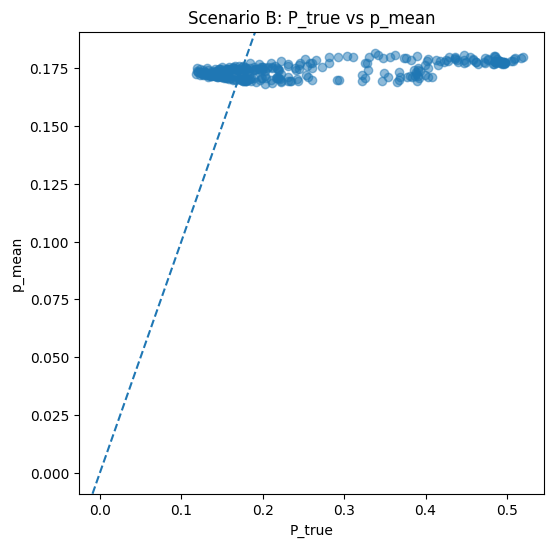

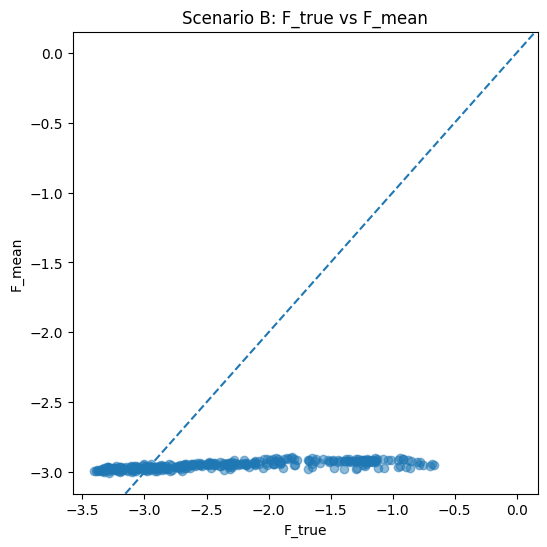

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(eval_B["P_true"], eval_B["p_mean"], alpha=0.5)
plt.xlabel("P_true")
plt.ylabel("p_mean")
plt.title("Scenario B: P_true vs p_mean")
plt.axline((0, 0), slope=1, linestyle="--")
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(eval_B["F_true"], eval_B["F_mean"], alpha=0.5)
plt.xlabel("F_true")
plt.ylabel("F_mean")
plt.title("Scenario B: F_true vs F_mean")
plt.axline((0, 0), slope=1, linestyle="--")
plt.show()